# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 2.0.1


In [3]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [4]:
# editing the args 
# in this experiement we increased the timesteps to 201 and the time to 40 which is double the original experiment to make sure we would capture the limit cycle 
args.dataset = 'isolated_repressilator'
args.folder = 'isolated_repressilator_bottleneck_exp'
args.time_steps = 201
args.prediction_length = 200
args.max_time = 40
args.num_samples = 15000
args.bottleneck = 100
args.decoder_loss_weight = 10
args.lr = 1e-3
args.epochs = 100
args.loss_function = 'mse'
args.unitary_loss_weight = 10
args.save = False


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [5]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [6]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 15000/15000 [00:00<00:00, 39696.51it/s]
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:130: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceT

the shape of the data is torch.Size([15000, 201, 6])
Processing dataset: isolated_repressilator
train_idx: 12000, val_idx: 13500
Processed data shapes - Train: torch.Size([12000, 201, 6]), Val: torch.Size([1500, 201, 6]), Test: torch.Size([1500, 201, 6])


## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [7]:
# Model definition with bottleneck size 100
ae_100 = AutoEncoder(
    input_size=input_size,
    encoded_size=100,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet_100 = Knet(size=100)
model_100 = torch.nn.ModuleDict({'ae': ae_100, 'knet': knet_100})
model_100 = model_100.to(device)
print("Created model_100 with bottleneck size 100")

# Model definition with bottleneck size 75
ae_75 = AutoEncoder(
    input_size=input_size,
    encoded_size=75,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet_75 = Knet(size=75)
model_75 = torch.nn.ModuleDict({'ae': ae_75, 'knet': knet_75})
model_75 = model_75.to(device)
print("Created model_75 with bottleneck size 75")

# Model definition with bottleneck size 50
ae_50 = AutoEncoder(
    input_size=input_size,
    encoded_size=50,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet_50 = Knet(size=50)
model_50 = torch.nn.ModuleDict({'ae': ae_50, 'knet': knet_50})
model_50 = model_50.to(device)
print("Created model_50 with bottleneck size 50")

# Model definition with bottleneck size 25
ae_25 = AutoEncoder(
    input_size=input_size,
    encoded_size=25,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet_25 = Knet(size=25)
model_25 = torch.nn.ModuleDict({'ae': ae_25, 'knet': knet_25})
model_25 = model_25.to(device)
print("Created model_25 with bottleneck size 25")

Created model_100 with bottleneck size 100
Created model_75 with bottleneck size 75
Created model_50 with bottleneck size 50
Created model_25 with bottleneck size 25


## Model Summary

Display the total number of parameters and the model architecture.

In [8]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_100.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_100.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model_100)
print('***************************')

# model 75
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_75.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_75.parameters())/1000.0))
print('************')
print('**** Model Architecture ****')
print(model_75)
print('***************************')
# model 50
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_50.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_50.parameters())/1000.0))
print('************')
print('**** Model Architecture ****')
print(model_50)
print('***************************')
# model 25
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model_25.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model_25.parameters())/1000.0))
print('************')
print('**** Model Architecture ****')
print(model_25)
print('***************************')

**** Setup ****
Total params: 0.05M
Total params: 51.71k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): Sequential(
      (0): MLP(
        (net): ModuleList(
          (0): Linear(in_features=6, out_features=100, bias=True)
          (1): LeakyReLU(negative_slope=0.01)
          (2): Linear(in_features=100, out_features=100, bias=True)
          (3): LeakyReLU(negative_slope=0.01)
          (4): Linear(in_features=100, out_features=100, bias=True)
        )
      )
      (1): Dropout(p=0.3, inplace=False)
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=100, out_features=6, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=100, out_features=100, bias=False)
  )
)
*****

## Training

Train the model using the `Trainer` class with the specified data loaders.

In [9]:
trainer_100 = Trainer(model_100, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_75 = Trainer(model_75, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_50 = Trainer(model_50, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer_25 = Trainer(model_25, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

Using the CPU
Using the CPU
Using the CPU
Using the CPU


In [10]:
print("Training models...")
print("Training model with bottleneck size 100")
stats_100 = trainer_100.train_KoopmanAE()[2]
print("Training model with bottleneck size 75")
stats_75 = trainer_75.train_KoopmanAE()[2]
print("Training model with bottleneck size 50")
stats_50 = trainer_50.train_KoopmanAE()[2]
print("Training model with bottleneck size 25")
stats_25 = trainer_25.train_KoopmanAE()[2]

Training models...
Training model with bottleneck size 100


Training Epochs:  20%|██        | 20/100 [08:38<35:04, 26.30s/it]

Epoch 20/100
Training - Recon Loss: 6.236968e-05, Linear Loss: 3.113833e-04, Pred Loss: 1.294193e-03, Unitary Loss: 4.211109e-04, Total Loss: 1.808812e-02
Validation - Recon Loss: 6.170606e-05, Linear Loss: 1.272637e-04, Pred Loss: 1.141899e-03,Unitary Loss: 4.197596e-04, Total Loss: 1.216331e-02


Training Epochs:  40%|████      | 40/100 [17:20<25:49, 25.83s/it]

Epoch 40/100
Training - Recon Loss: 6.337848e-05, Linear Loss: 2.655429e-04, Pred Loss: 6.993596e-04, Unitary Loss: 3.587381e-04, Total Loss: 1.148030e-02
Validation - Recon Loss: 5.818559e-05, Linear Loss: 1.211500e-04, Pred Loss: 8.663110e-04,Unitary Loss: 3.563514e-04, Total Loss: 9.366117e-03


...

Epoch 60/100
Training - Recon Loss: 1.243678e-04, Linear Loss: 4.238077e-04, Pred Loss: 6.671624e-04, Unitary Loss: 4.894819e-05, Total Loss: 8.828591e-03
Validation - Recon Loss: 6.689034e-05, Linear Loss: 2.657374e-04, Pred Loss: 5.032288e-04,Unitary Loss: 5.026804e-05, Total Loss: 5.966928e-03


Training Epochs:  80%|████████  | 80/100 [12:17<02:48,  8.42s/it]

Epoch 80/100
Training - Recon Loss: 1.209159e-04, Linear Loss: 3.842896e-04, Pred Loss: 6.397851e-04, Unitary Loss: 4.969415e-05, Total Loss: 8.488241e-03
Validation - Recon Loss: 7.533271e-05, Linear Loss: 3.617564e-04, Pred Loss: 4.872395e-04,Unitary Loss: 4.990427e-05, Total Loss: 5.987479e-03


Training Epochs: 100%|██████████| 100/100 [15:22<00:00,  9.23s/it]

Epoch 100/100
Training - Recon Loss: 1.102226e-04, Linear Loss: 3.667093e-04, Pred Loss: 5.286239e-04, Unitary Loss: 5.210779e-05, Total Loss: 7.276252e-03
Validation - Recon Loss: 7.558448e-05, Linear Loss: 3.163448e-04, Pred Loss: 3.831619e-04,Unitary Loss: 5.734533e-05, Total Loss: 4.903808e-03


In [11]:

print("Testing models...")
print("Testing model with bottleneck size 100")
trainer_100.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 75")
trainer_75.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 50")
trainer_50.test_KoopmanAE(test_loader)
print("Testing model with bottleneck size 25")
trainer_25.test_KoopmanAE(test_loader)

Testing models...
Testing model with bottleneck size 100
Test - Recon Loss: 1.235149e-05, Linear Loss: 1.102768e-04, Pred Loss: 3.395561e-04, Total Loss: 3.629353e-03
Testing model with bottleneck size 75
Test - Recon Loss: 2.959215e-05, Linear Loss: 2.557990e-04, Pred Loss: 4.485260e-04, Total Loss: 5.036981e-03
Testing model with bottleneck size 50
Test - Recon Loss: 3.250341e-05, Linear Loss: 1.298796e-04, Pred Loss: 2.376910e-04, Total Loss: 2.831824e-03
Testing model with bottleneck size 25
Test - Recon Loss: 7.720759e-05, Linear Loss: 3.498921e-04, Pred Loss: 4.011958e-04, Total Loss: 5.133926e-03


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

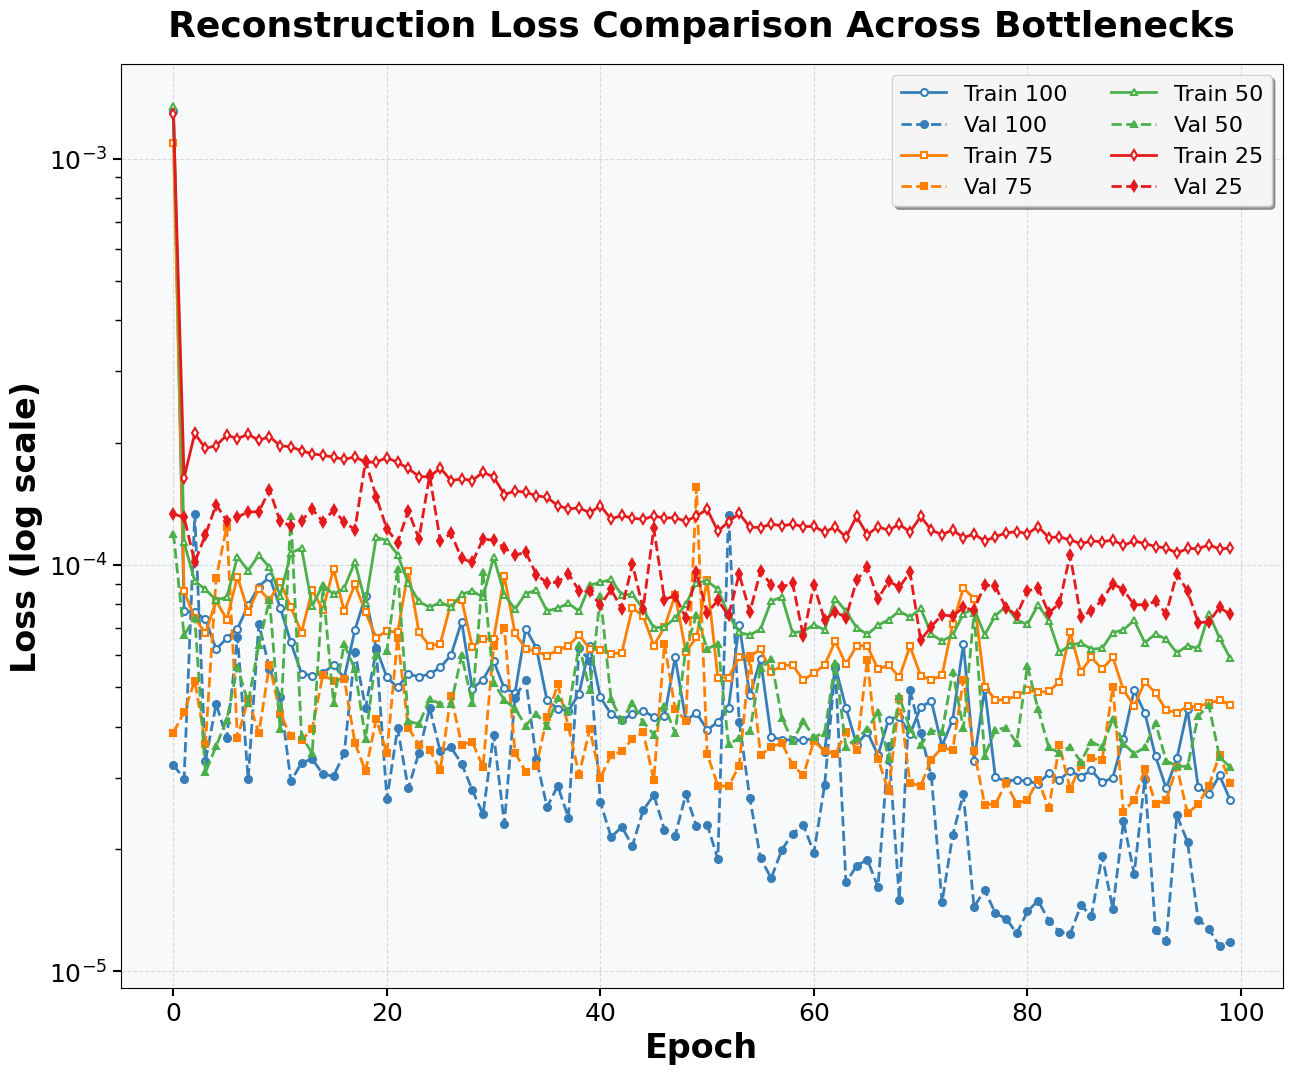

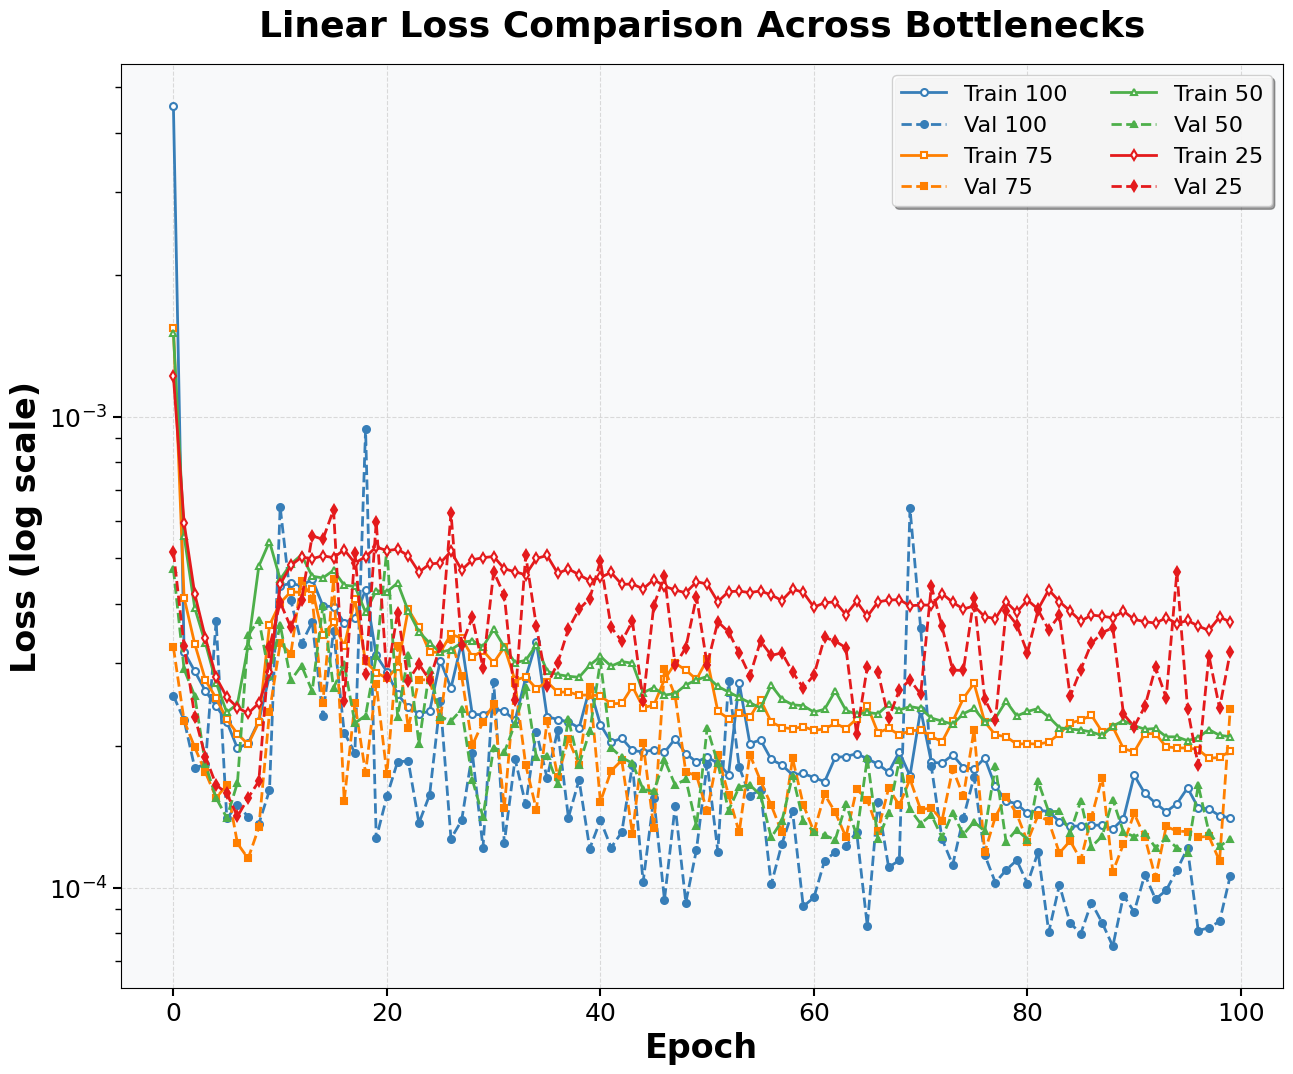

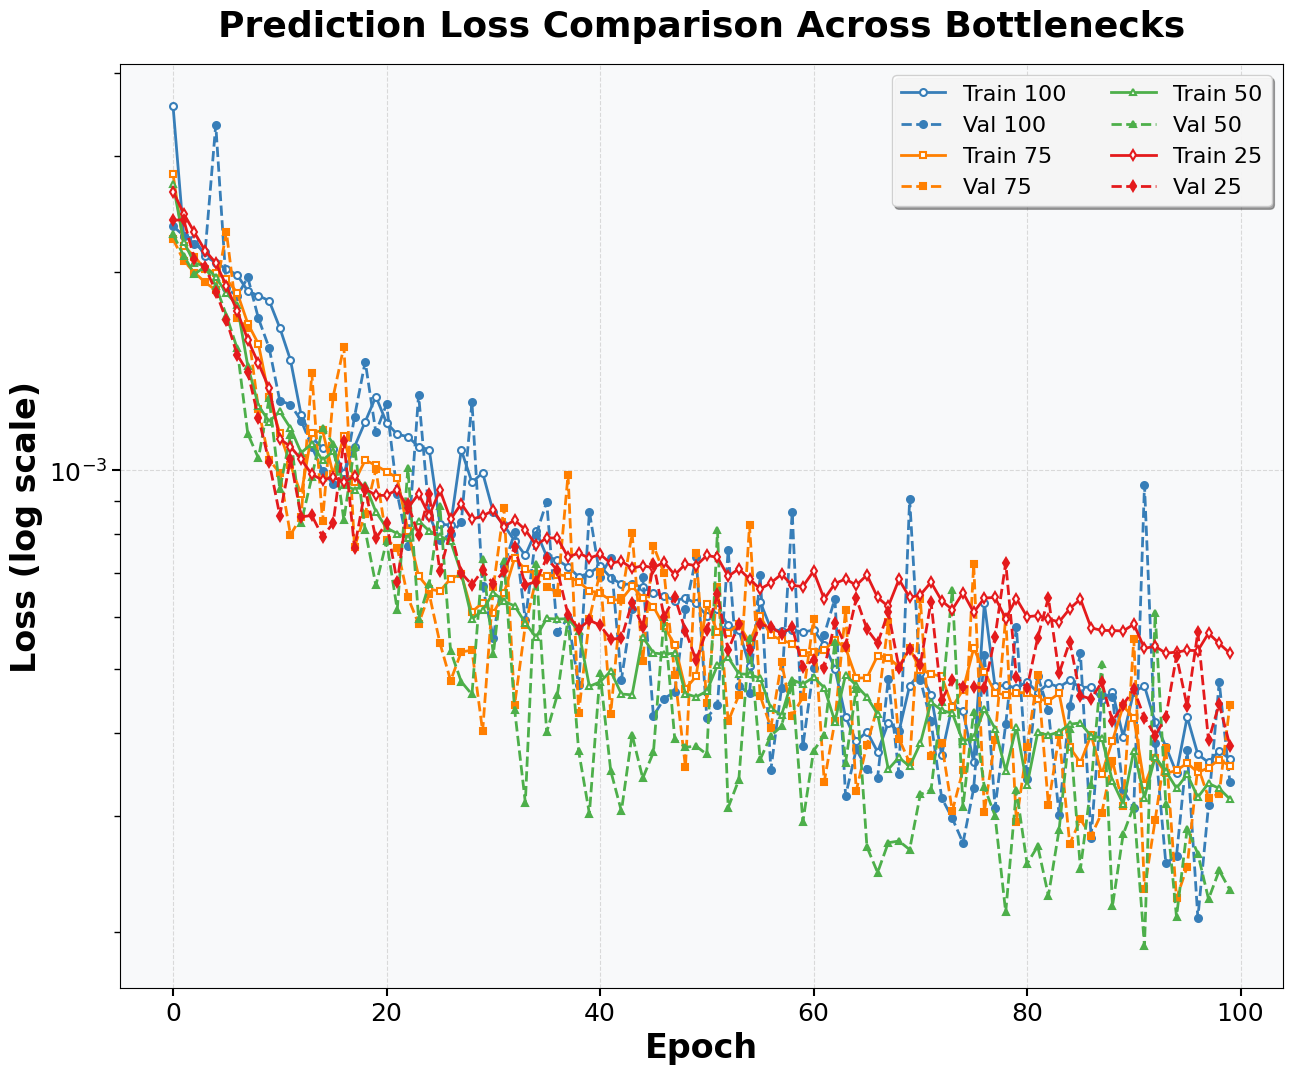

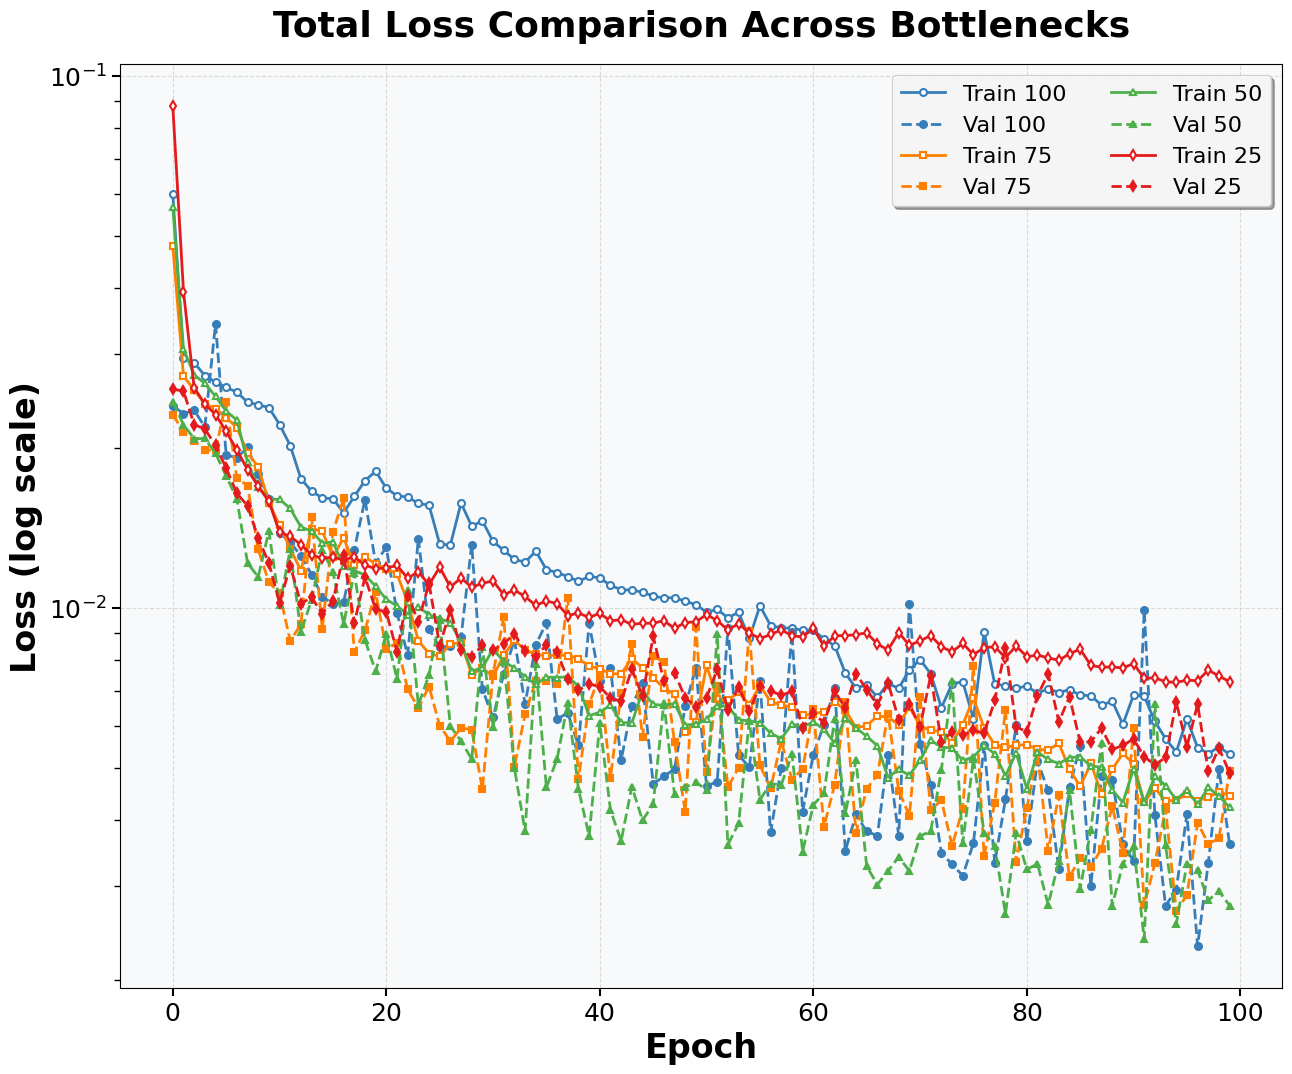

Generated comparison loss plots.


In [12]:
def plot_comparison_losses(stats_dict, loss_base_name, folder_path, save=True):
    """
    Plots training and validation losses for a specific loss type across multiple models.

    Args:
        stats_dict (dict): A dictionary where keys are model identifiers (e.g., '100', '75')
                           and values are the corresponding stats dictionaries from training.
        loss_base_name (str): The base name of the loss (e.g., 'recon_loss', 'lin_loss').
        folder_path (str): Path to the folder where the plot should be saved.
        save (bool): Whether to save the plot.
    """
    fig = plt.figure(figsize=(15, 12))
    ax = plt.gca()
    
    colors = {'100': '#377eb8', '75': '#ff7f00', '50': '#4daf4a', '25': '#e41a1c'}
    linestyles_tr = {'100': '-', '75': '-', '50': '-', '25': '-'}
    linestyles_va = {'100': '--', '75': '--', '50': '--', '25': '--'}
    markers = {'100': 'o', '75': 's', '50': '^', '25': 'd'}
    
    loss_title_map = {
        'recon_loss': 'Reconstruction',
        'lin_loss': 'Linear',
        'pred_loss': 'Prediction',
        'total_loss': 'Total'
    }
    plot_title = loss_title_map.get(loss_base_name, loss_base_name.replace('_', ' ').title())

    for model_id, stats in stats_dict.items():
        loss_tr_key = f'{loss_base_name}_tr'
        loss_va_key = f'{loss_base_name}_va'
        
        if loss_tr_key in stats:
            loss_tr = np.array(stats[loss_tr_key])
            # Handle potential non-positive values for log scale
            if np.any(loss_tr <= 0):
                 min_positive = np.min(loss_tr[loss_tr > 0]) / 10 if np.any(loss_tr > 0) else 1e-10
                 loss_tr = np.maximum(loss_tr, min_positive)
            
            ax.semilogy(loss_tr, lw=2, marker=markers[model_id], markersize=5,
                        markerfacecolor='white', markeredgewidth=1.5,
                        markeredgecolor=colors[model_id], linestyle=linestyles_tr[model_id],
                        label=f'Train {model_id}', color=colors[model_id])

        if loss_va_key in stats:
            loss_va = np.array(stats[loss_va_key])
             # Handle potential non-positive values for log scale
            if np.any(loss_va <= 0):
                 min_positive = np.min(loss_va[loss_va > 0]) / 10 if np.any(loss_va > 0) else 1e-10
                 loss_va = np.maximum(loss_va, min_positive)

            ax.semilogy(loss_va, lw=2, marker=markers[model_id], markersize=5,
                        markerfacecolor=colors[model_id], markeredgewidth=1.5,
                        markeredgecolor=colors[model_id], linestyle=linestyles_va[model_id],
                        label=f'Val {model_id}', color=colors[model_id])

    # Styling
    ax.grid(True, linestyle='--', alpha=0.7, color='#cccccc')
    ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', width=1, length=4)
    ax.set_ylabel('Loss (log scale)', fontsize=24, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=24, fontweight='bold')
    ax.set_facecolor('#f8f9fa')
    ax.set_title(f'{plot_title} Loss Comparison Across Bottlenecks', fontsize=26, fontweight='bold', pad=20)
    ax.legend(fontsize=16, frameon=True, fancybox=True, framealpha=0.9,
              shadow=True, loc='upper right', ncol=2) # Adjust ncol if needed
    ax.yaxis.set_minor_locator(plt.LogLocator(base=10, subs=np.arange(1, 10)*0.1))

    # Save figure
    if save:
        save_path = os.path.join(folder_path, f'{loss_base_name}_comparison_log_scale.png')
        fig.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to {save_path}")
    plt.show()
    plt.close(fig)

# --- Add this cell to your notebook after training all models ---

# Assuming you have: stats_100, stats_75, stats_50, stats_25
all_stats = {
    '100': stats_100,
    '75': stats_75,
    '50': stats_50,
    '25': stats_25
}

# Define the base folder for saving plots (use the one defined earlier)
comparison_folder_path = folder_path # Or specify a new subfolder if desired

# Create the plots
plot_comparison_losses(all_stats, 'recon_loss', comparison_folder_path, save=args.save)
plot_comparison_losses(all_stats, 'lin_loss', comparison_folder_path, save=args.save)
plot_comparison_losses(all_stats, 'pred_loss', comparison_folder_path, save=args.save)
plot_comparison_losses(all_stats, 'total_loss', comparison_folder_path, save=args.save)

print("Generated comparison loss plots.")

### Long Term Prediction on the Repressilator up to 1000 timestep

Generating 10 trajectories...


100%|██████████| 10/10 [00:00<00:00, 53.74it/s]


Dataset saved to disk.
Evaluating model: Model 100


100%|██████████| 10/10 [00:00<00:00, 35.17it/s]


Evaluating model: Model 75


100%|██████████| 10/10 [00:00<00:00, 38.24it/s]


Evaluating model: Model 50


100%|██████████| 10/10 [00:00<00:00, 38.91it/s]


Evaluating model: Model 25


100%|██████████| 10/10 [00:00<00:00, 36.61it/s]


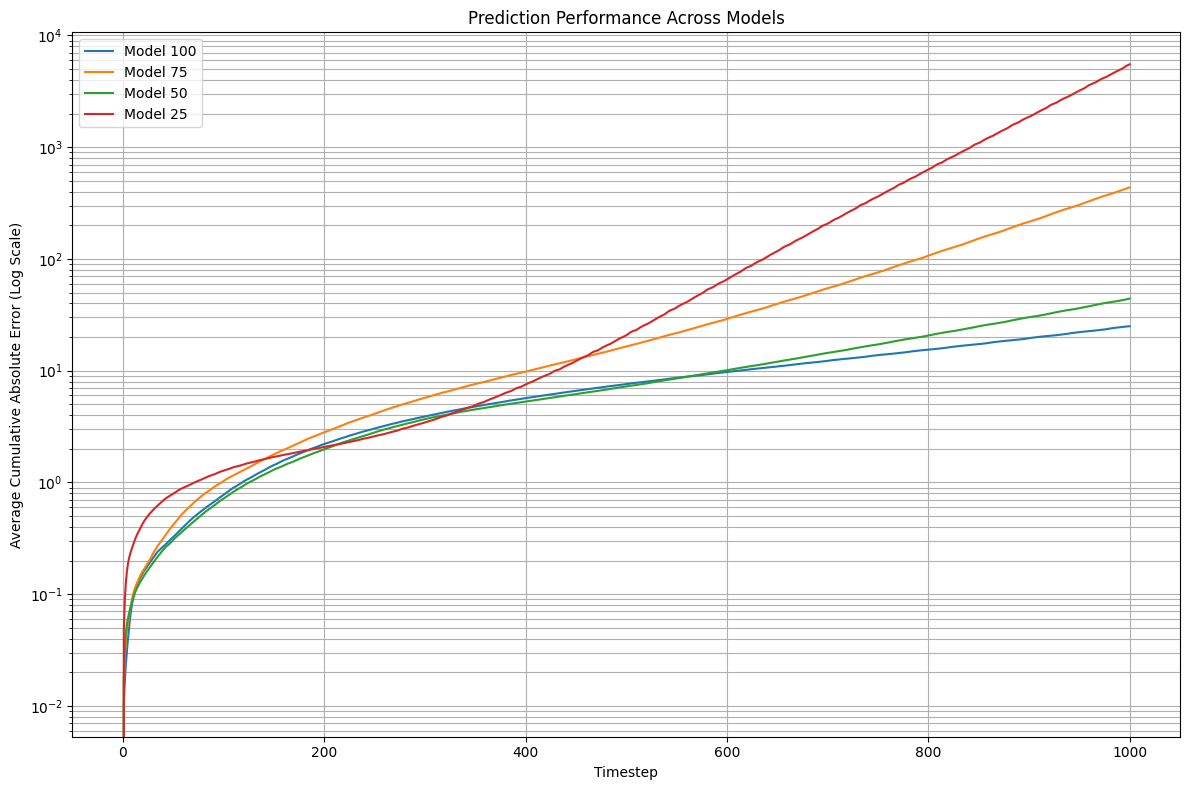

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils.data_loader import RepressilatorModel
import os

def generate_dataset(num_trajectories=1000, time_points=1001, time_span=200):
    """
    Generate a dataset of multiple trajectories from the Repressilator model.
    
    Args:
        num_trajectories: Number of trajectories to generate
        time_points: Number of time points in each trajectory
        time_span: Total time span for simulation
        
    Returns:
        trajectories: numpy array of shape (num_trajectories, time_points, 6)
    """
    print(f"Generating {num_trajectories} trajectories...")
    trajectories = np.zeros((num_trajectories, time_points, 6))
    times = np.linspace(0, time_span, time_points)
    
    for i in tqdm(range(num_trajectories)):
        # Random initial conditions
        y0 = np.random.rand(6) * 100
        
        # Create model and simulate
        repressilator_model = RepressilatorModel(y0=y0)
        parameters = repressilator_model.suggested_parameters()
        traj = repressilator_model.simulate(parameters, times)
        
        # Normalize
        traj = traj/data_handler.Xscale
        
        # Store trajectory
        trajectories[i] = traj
        
    return trajectories, times

def evaluate_models(trajectories, models_dict, device="cuda"):
    """
    Evaluate multiple models on the generated trajectories using absolute cumulative error.
    
    Args:
        trajectories: numpy array of shape (num_trajectories, time_points, 6)
        models_dict: dictionary containing model and trainer pairs
        device: device to run computations on
        
    Returns:
        results: dictionary with evaluation metrics for each model
    """
    num_trajectories, time_points, _ = trajectories.shape
    results = {}
    
    for model_name, (_, trainer) in models_dict.items():
        print(f"Evaluating model: {model_name}")
        
        # Initialize arrays to store losses
        prediction_errors = np.zeros((num_trajectories, time_points))
        cumulative_errors = np.zeros((num_trajectories, time_points))
        
        # Evaluate each trajectory
        for i in tqdm(range(num_trajectories)):
            # Convert to tensor
            traj = torch.tensor(trajectories[i], dtype=torch.float32).to(device)
            
            # Get predicted trajectory
            predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)
            
            # Convert to numpy for error calculation
            traj_np = traj.cpu().detach().numpy()
            predicted_traj_np = predicted_traj.cpu().detach().numpy()
            
            # Calculate absolute error at each time step and make it cumulative
            cumulative_error = 0
            for t in range(time_points):
                # Single timestep absolute prediction error
                if t < len(predicted_traj_np):
                    # Mean absolute error across all state variables
                    error = np.mean(np.abs(traj_np[t] - predicted_traj_np[t]))
                    prediction_errors[i, t] = error
                    
                    # Add to cumulative error
                    cumulative_error += error
                    cumulative_errors[i, t] = cumulative_error
        
        # Calculate average errors across all trajectories
        avg_prediction_error = np.mean(prediction_errors, axis=0)
        avg_cumulative_error = np.mean(cumulative_errors, axis=0)
        
        # Store results
        results[model_name] = {
            'avg_prediction_error': avg_prediction_error,
            'avg_cumulative_error': avg_cumulative_error
        }
    
    return results

def plot_results(results):
    """
    Plot the average cumulative absolute error for each model using a log scale.
    
    Args:
        results: dictionary with evaluation metrics for each model
    """
    plt.figure(figsize=(12, 8))
    
    # Get the number of timesteps from the first model result
    timesteps = len(next(iter(results.values()))['avg_cumulative_error'])
    timestep_indices = np.arange(timesteps)
    
    # Plot cumulative absolute errors with log scale on y-axis
    for model_name, metrics in results.items():
        plt.semilogy(timestep_indices, metrics['avg_cumulative_error'], label=model_name)
    
    plt.xlabel('Timestep')
    plt.ylabel('Average Cumulative Absolute Error (Log Scale)')
    plt.title('Prediction Performance Across Models')
    plt.legend()
    plt.grid(True, which="both", ls="-")
    
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'model_prediction_comparison_log.png'), dpi=300)
    plt.show()

# Main execution function - use this with your pre-loaded models
def evaluate_repressilator_models(model_100, trainer_100, model_75, trainer_75, 
                                 model_50, trainer_50, model_25, trainer_25,
                                 num_trajectories=1000, device="cuda"):
    """
    Main function to evaluate pre-loaded models on Repressilator trajectories,
    focusing on absolute cumulative prediction error.
    
    Args:
        model_X: Pre-loaded models
        trainer_X: Pre-loaded trainers
        num_trajectories: Number of trajectories to generate
        device: Device to run computations on
    """
    # Create dictionary of models and trainers
    models_dict = {
        "Model 100": (model_100, trainer_100),
        "Model 75": (model_75, trainer_75),
        "Model 50": (model_50, trainer_50),
        "Model 25": (model_25, trainer_25)
    }
    
    # Generate dataset
    trajectories, _ = generate_dataset(num_trajectories=num_trajectories)
    
    # Save the dataset
    np.save('repressilator_trajectories.npy', trajectories)
    print("Dataset saved to disk.")
    
    # Evaluate models
    results = evaluate_models(trajectories, models_dict, device)
    
    # Plot results
    plot_results(results)
    
    # Optionally, save the results
    #np.save('prediction_evaluation_results.npy', results)
    #print("Evaluation complete. Results saved to disk.")
    
    return trajectories, results

# Example usage:
trajectories, results = evaluate_repressilator_models(
     model_100, trainer_100, model_75, trainer_75, 
     model_50, trainer_50, model_25, trainer_25, num_trajectories=10, device=device
)

## Example of using each model

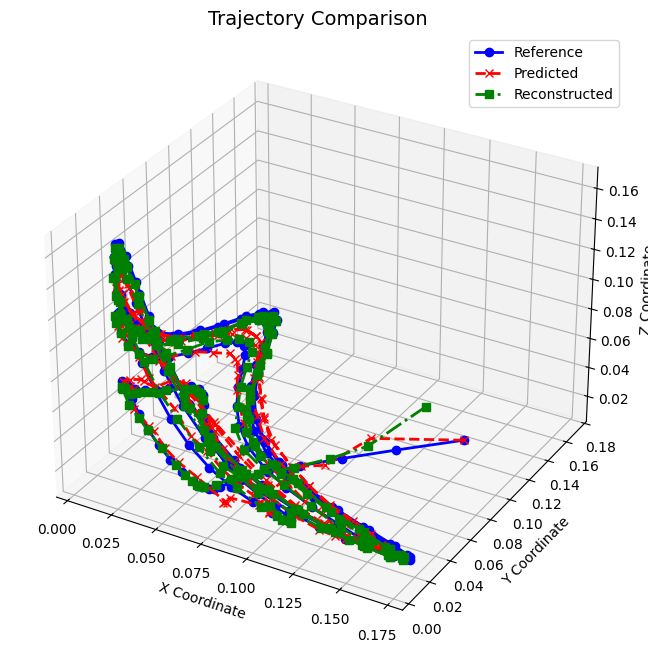

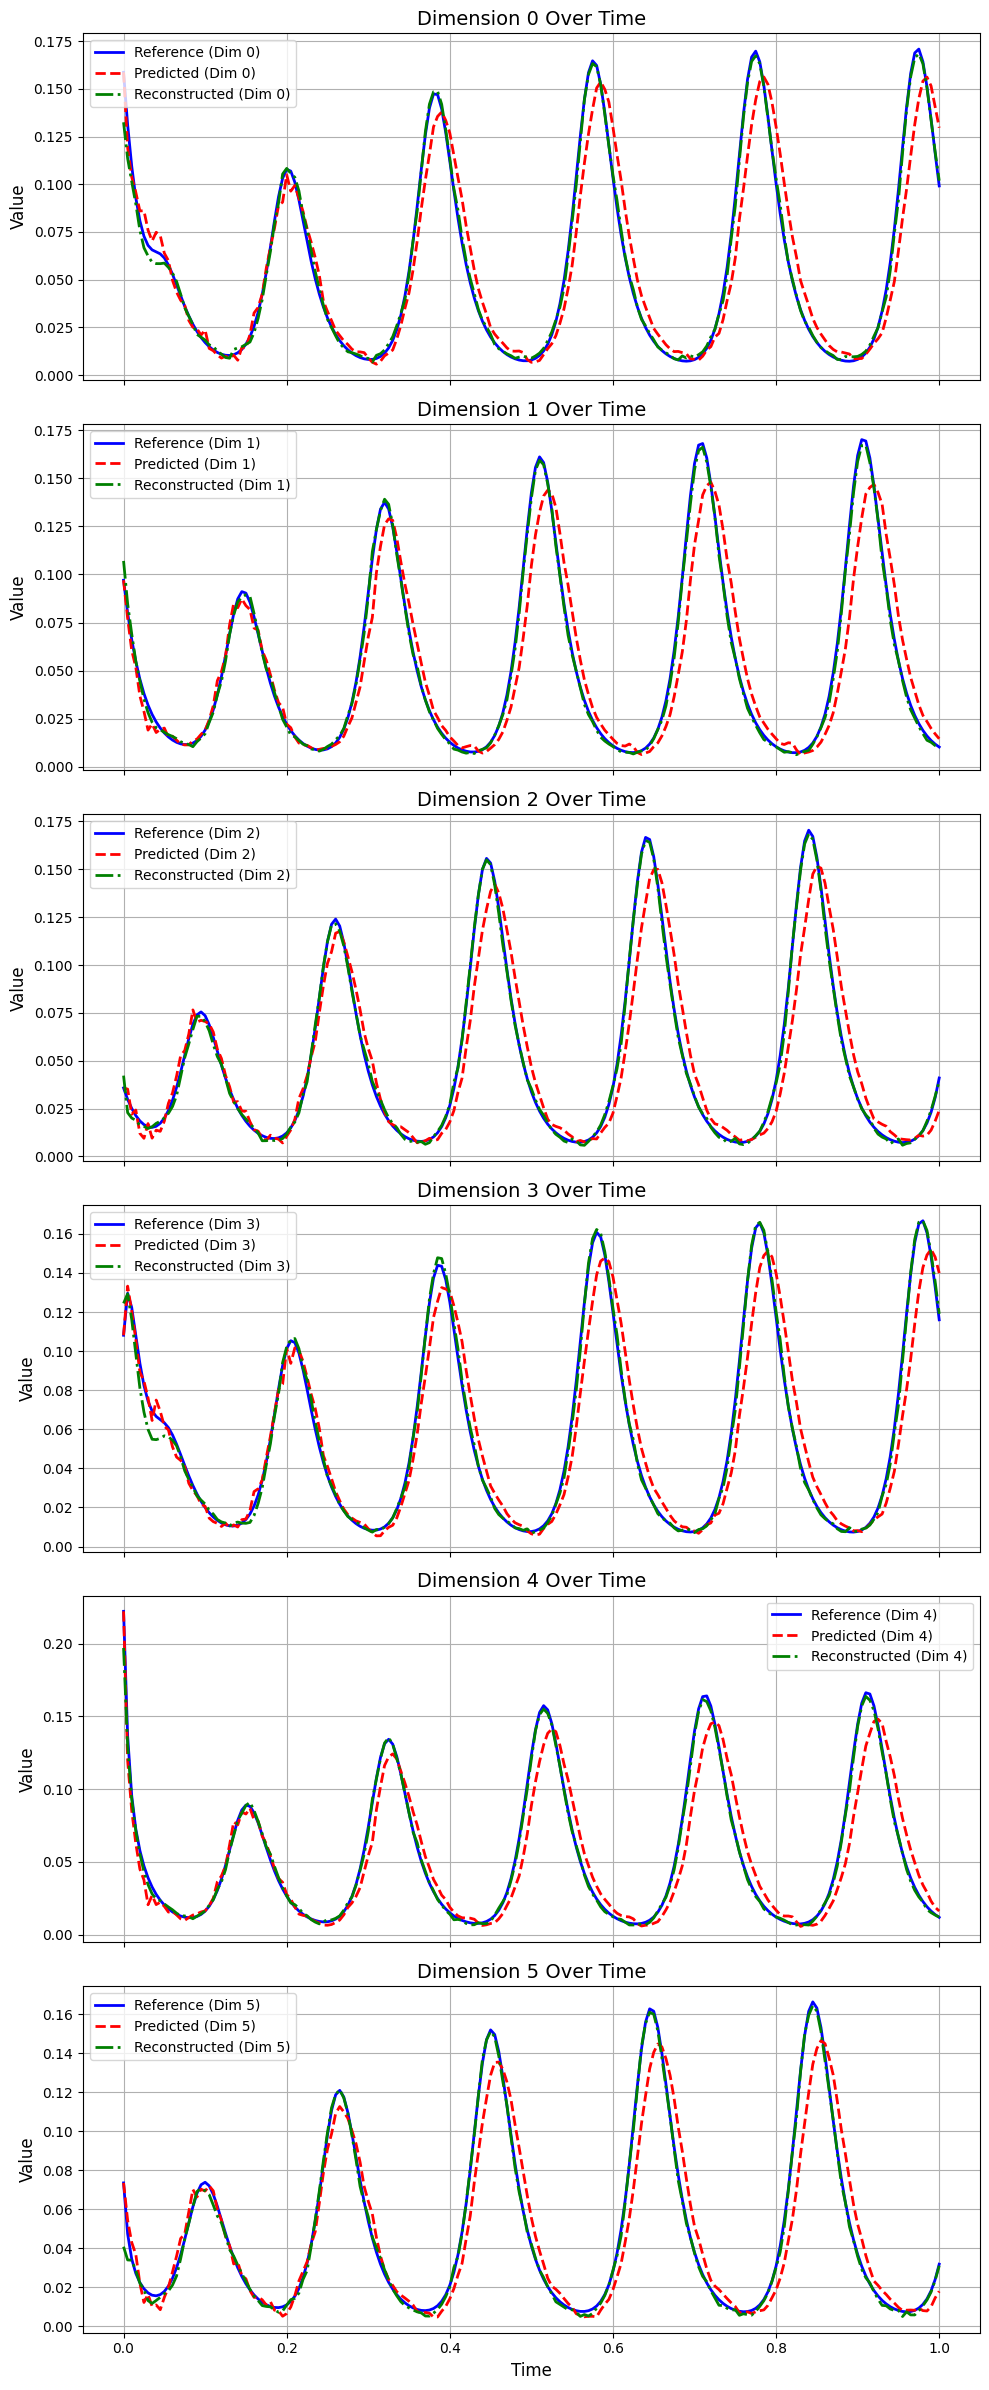

In [14]:
# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model_100.eval()
with torch.no_grad():
    Y, reconstructed_traj = model_100.ae(traj)


# Get predicted trajectory
predicted_traj = trainer_100.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

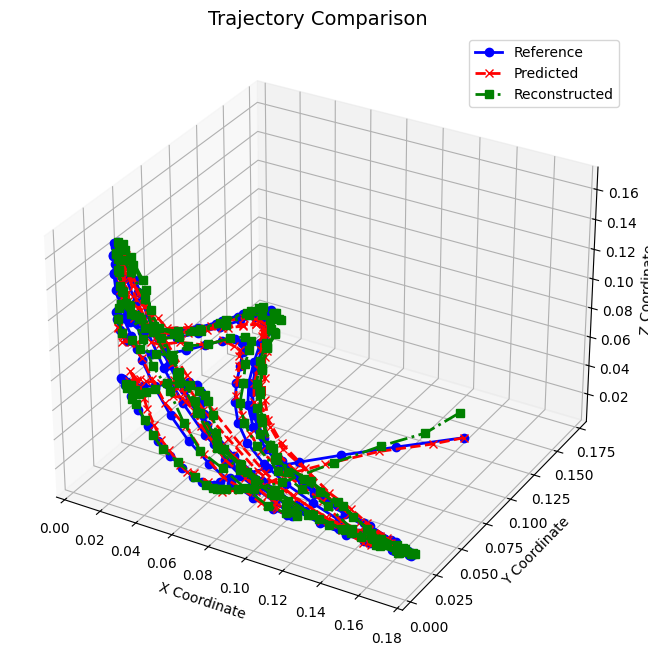

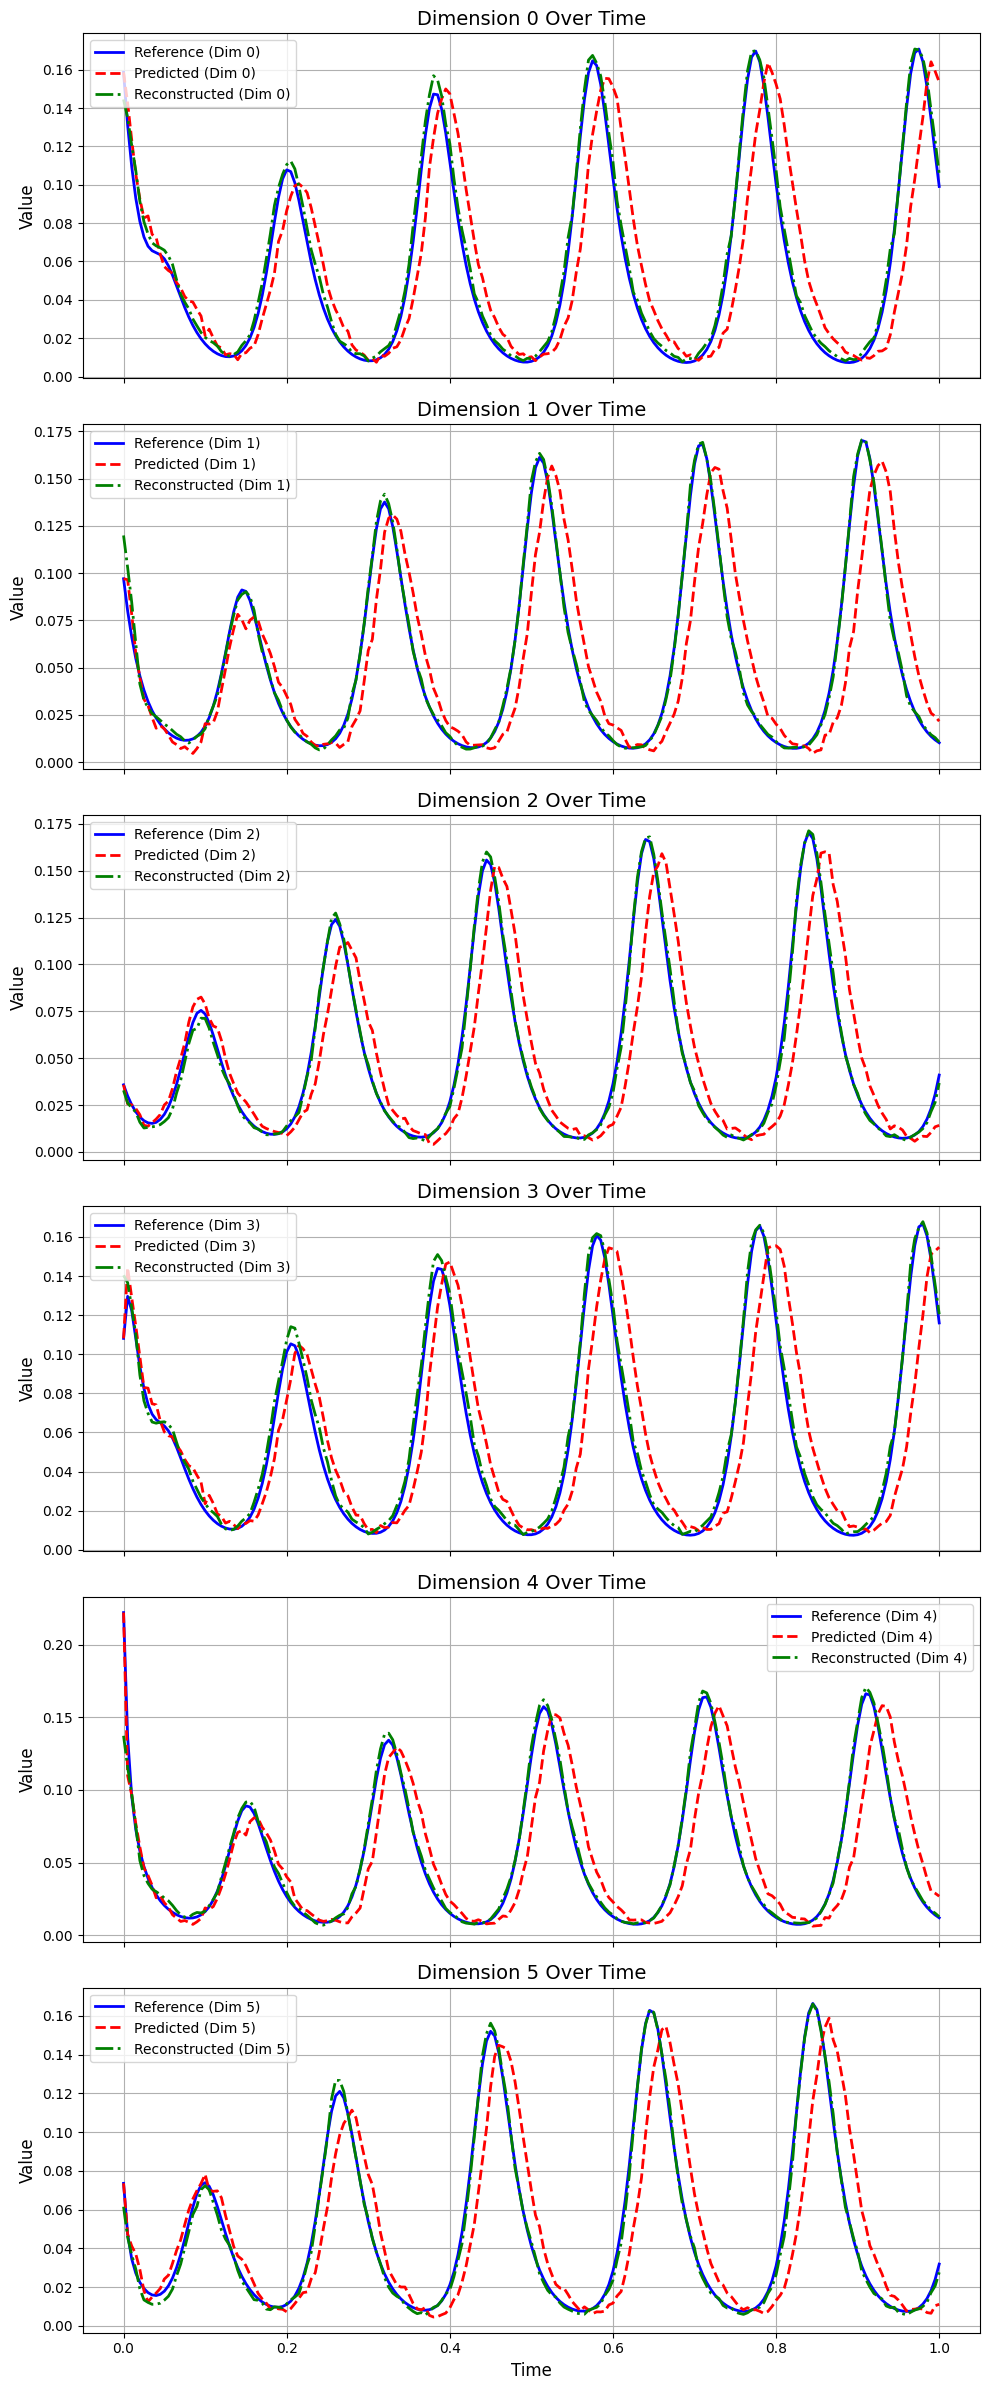

In [15]:
# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model_75.eval()
with torch.no_grad():
    Y, reconstructed_traj = model_75.ae(traj)


# Get predicted trajectory
predicted_traj = trainer_75.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

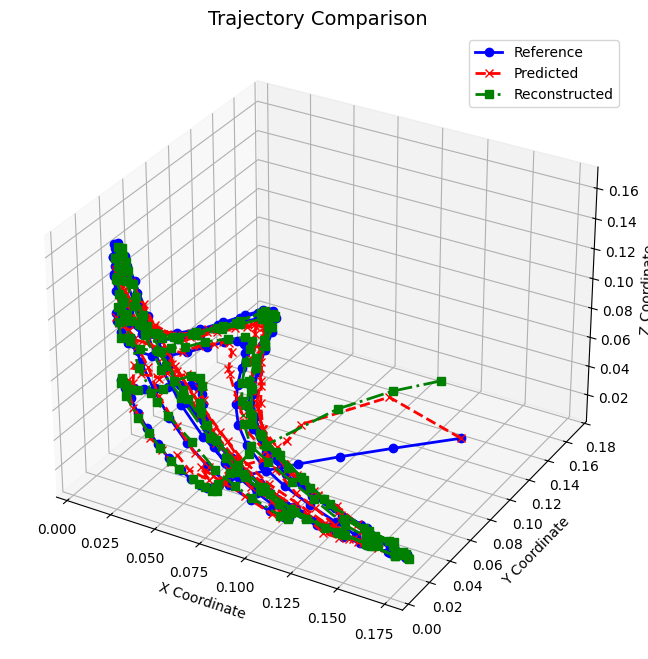

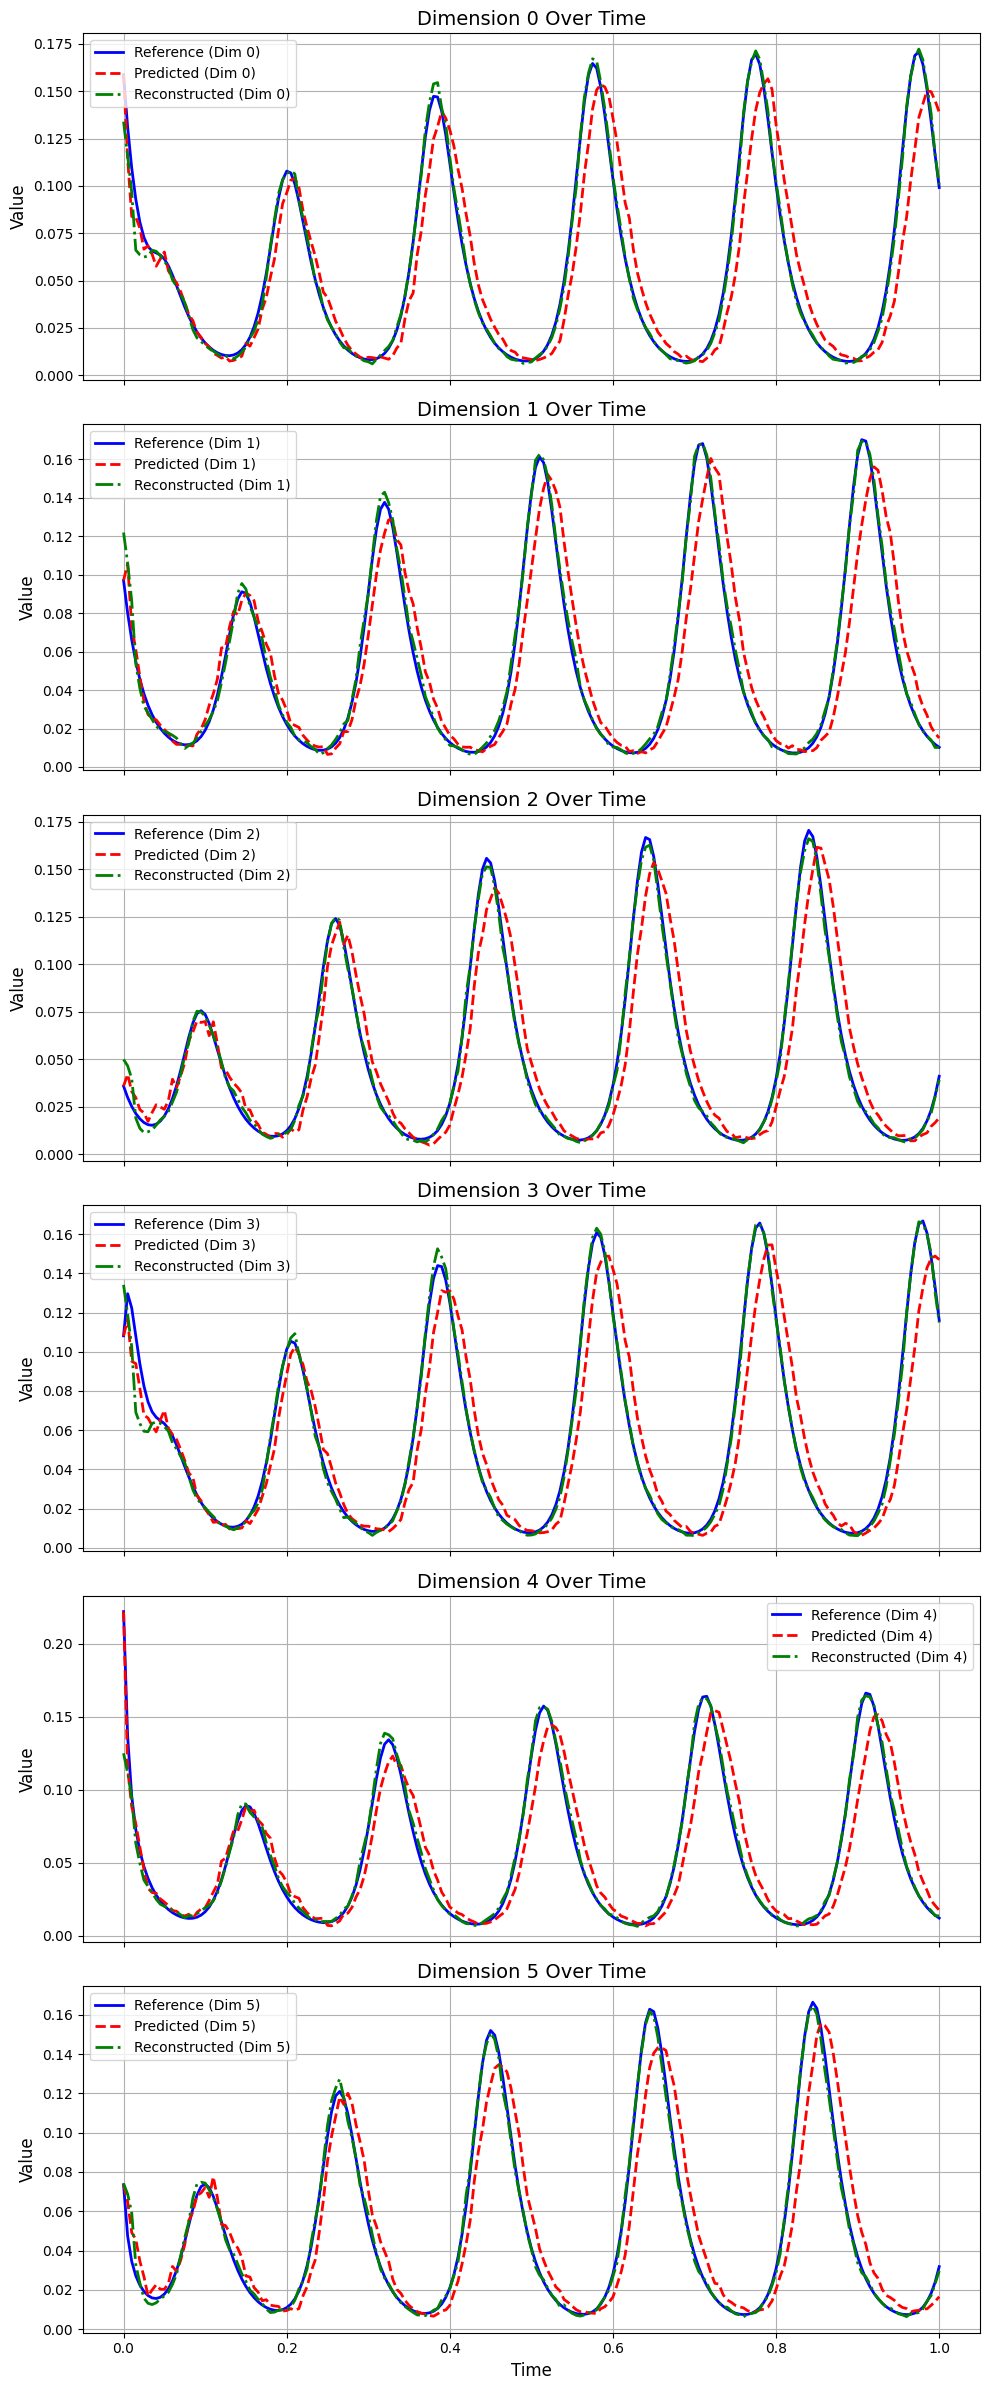

In [16]:
# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model_50.eval()
with torch.no_grad():
    Y, reconstructed_traj = model_50.ae(traj)


# Get predicted trajectory
predicted_traj = trainer_50.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

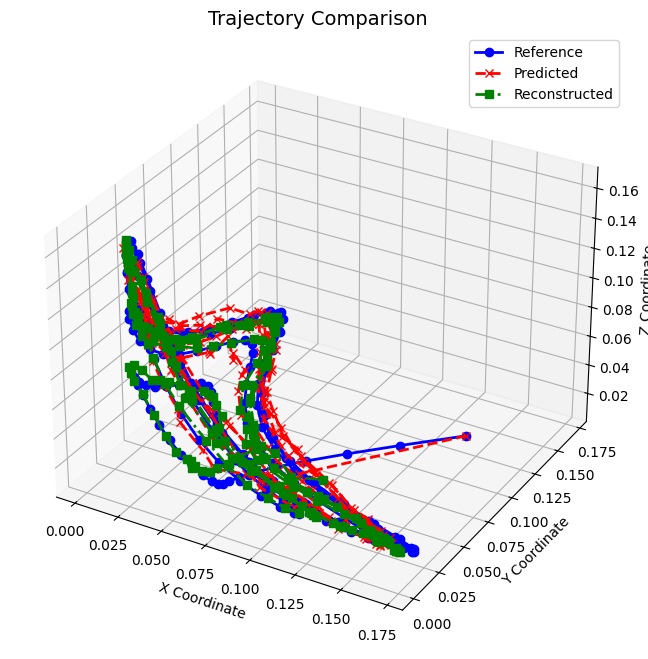

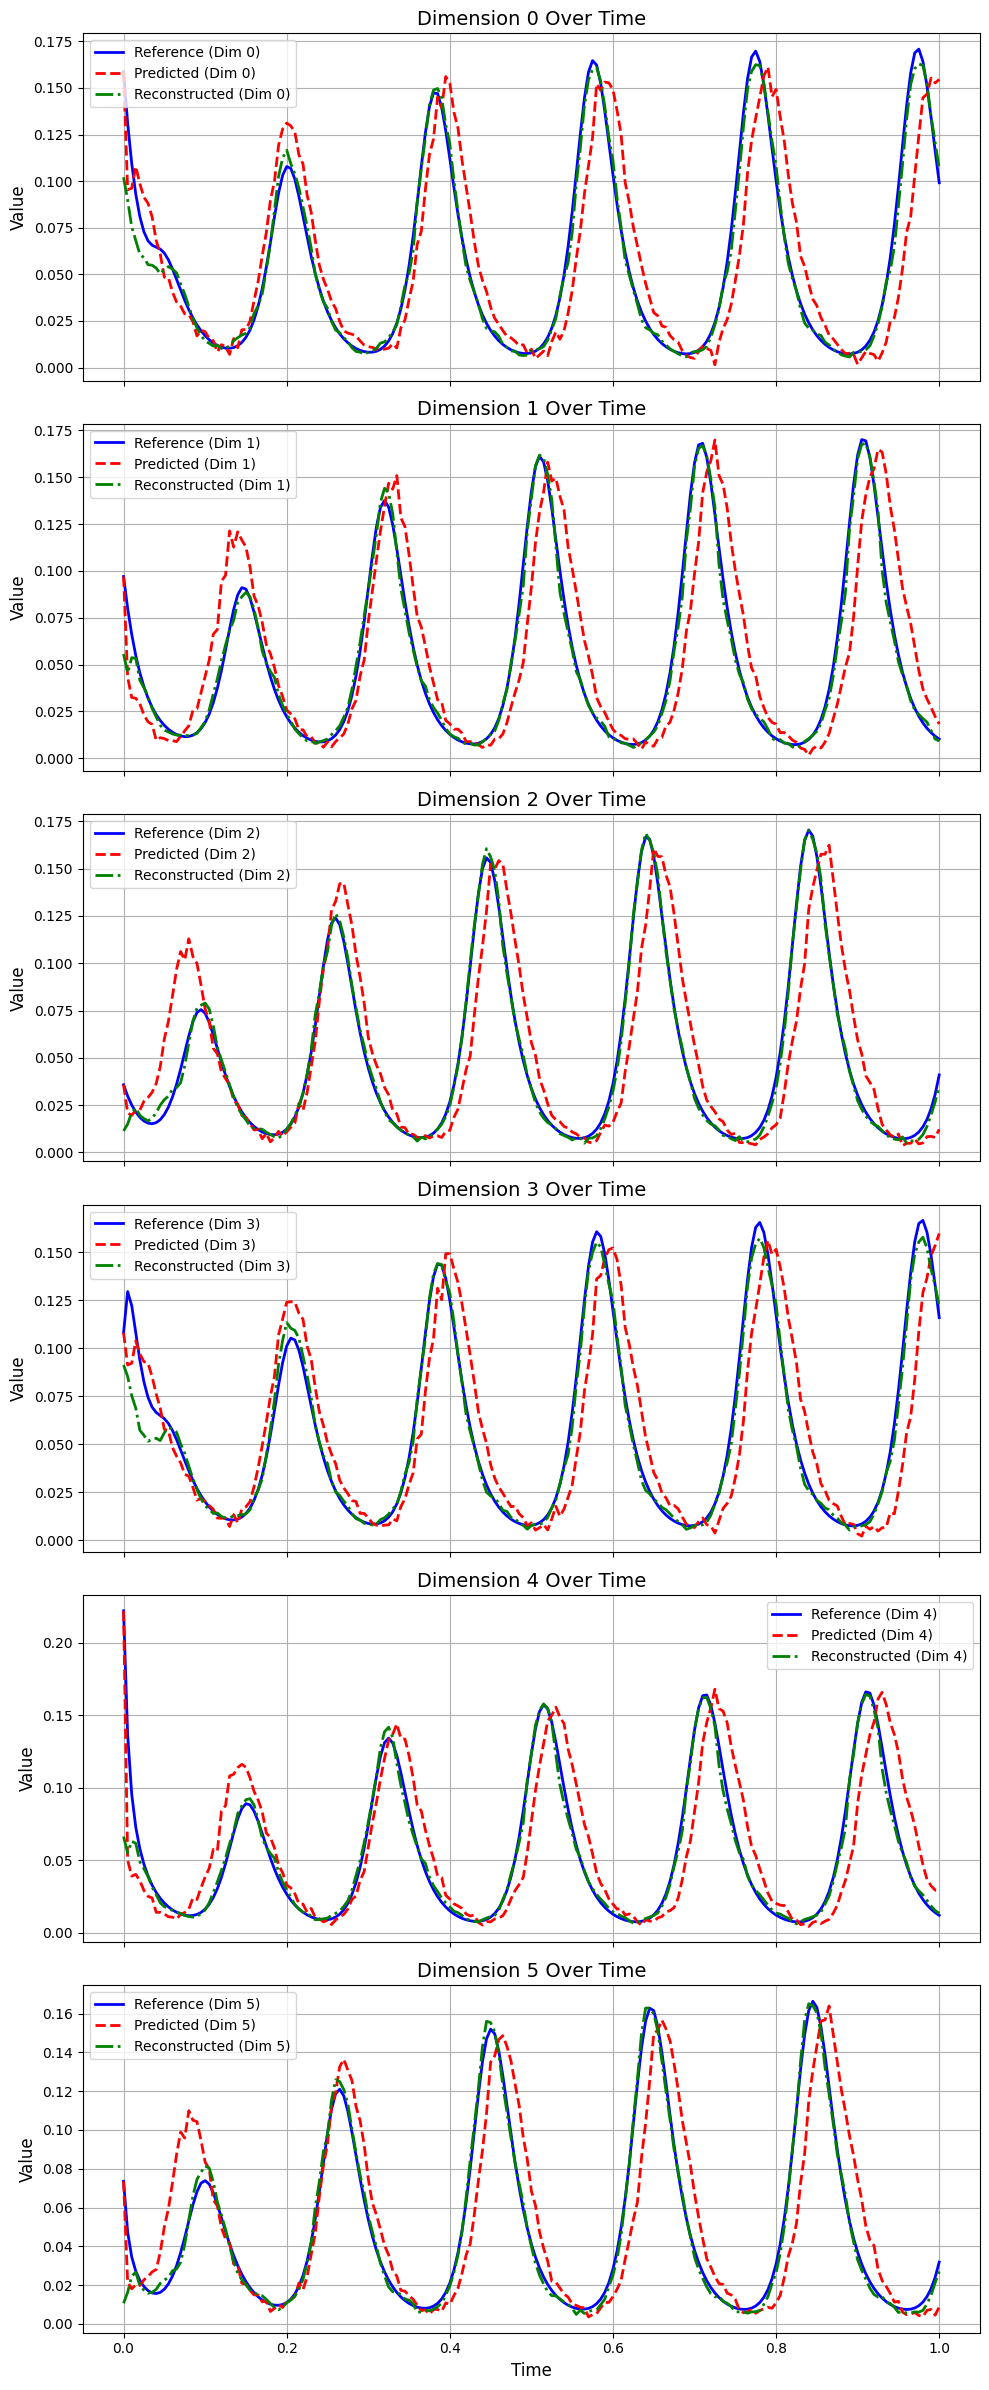

In [17]:
# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model_25.eval()
with torch.no_grad():
    Y, reconstructed_traj = model_25.ae(traj)


# Get predicted trajectory
predicted_traj = trainer_25.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)